In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('concertriccir2.csv')

In [4]:
df.columns = ['X', 'Y','class']
df.head()

,X,Y,class
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


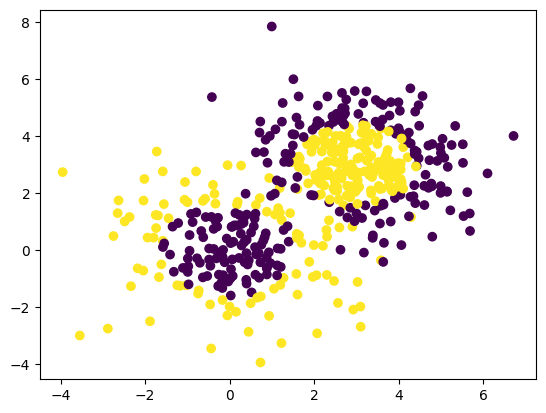

In [7]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
x = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

# Without Batch Normalization

In [9]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 15
Trainable params: 15
Non-trainable params: 0
_________________________________________________________________


In [10]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [12]:
history1 = model.fit(x,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 [==============================] - 3s 39ms/step - loss: 0.7899 - accuracy: 0.4185 - val_loss: 0.8934 - val_accuracy: 0.4200
Epoch 2/200
13/13 [==============================] - 0s 14ms/step - loss: 0.7794 - accuracy: 0.4236 - val_loss: 0.8778 - val_accuracy: 0.4100
Epoch 3/200
13/13 [==============================] - 0s 14ms/step - loss: 0.7707 - accuracy: 0.4185 - val_loss: 0.8591 - val_accuracy: 0.4000
Epoch 4/200
13/13 [==============================] - 0s 13ms/step - loss: 0.7620 - accuracy: 0.4135 - val_loss: 0.8452 - val_accuracy: 0.4000
Epoch 5/200
13/13 [==============================] - 0s 15ms/step - loss: 0.7543 - accuracy: 0.4110 - val_loss: 0.8279 - val_accuracy: 0.3900
Epoch 6/200
13/13 [==============================] - 0s 13ms/step - loss: 0.7472 - accuracy: 0.4060 - val_loss: 0.8127 - val_accuracy: 0.3700
Epoch 7/200
13/13 [==============================] - 0s 14ms/step - loss: 0.7405 - accuracy: 0.4060 - val_loss: 0.7995 - val_accuracy: 0.3800
Epoch 

# With Batch Normalization

In [13]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 3)                 9         
                                                                 
 batch_normalization (BatchN  (None, 3)                12        
 ormalization)                                                   
                                                                 
 dense_4 (Dense)             (None, 2)                 8         
                                                                 
 batch_normalization_1 (Batc  (None, 2)                8         
 hNormalization)                                                 
                                                                 
 dense_5 (Dense)             (None, 1)                 3         
                                                                 
Total params: 40
Trainable params: 30
Non-trainable pa

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [16]:
history2 = model.fit(x,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 [==============================] - 1s 20ms/step - loss: 1.0164 - accuracy: 0.4286 - val_loss: 1.0558 - val_accuracy: 0.5700
Epoch 2/200
13/13 [==============================] - 0s 8ms/step - loss: 0.9801 - accuracy: 0.4662 - val_loss: 0.9505 - val_accuracy: 0.5700
Epoch 3/200
13/13 [==============================] - 0s 9ms/step - loss: 0.9398 - accuracy: 0.4386 - val_loss: 0.8771 - val_accuracy: 0.5300
Epoch 4/200
13/13 [==============================] - 0s 9ms/step - loss: 0.9401 - accuracy: 0.4511 - val_loss: 0.8261 - val_accuracy: 0.5200
Epoch 5/200
13/13 [==============================] - 0s 8ms/step - loss: 0.9071 - accuracy: 0.4586 - val_loss: 0.7877 - val_accuracy: 0.4900
Epoch 6/200
13/13 [==============================] - 0s 8ms/step - loss: 0.8349 - accuracy: 0.4737 - val_loss: 0.7562 - val_accuracy: 0.4800
Epoch 7/200
13/13 [==============================] - 0s 8ms/step - loss: 0.8040 - accuracy: 0.4812 - val_loss: 0.7310 - val_accuracy: 0.4600
Epoch 8/200


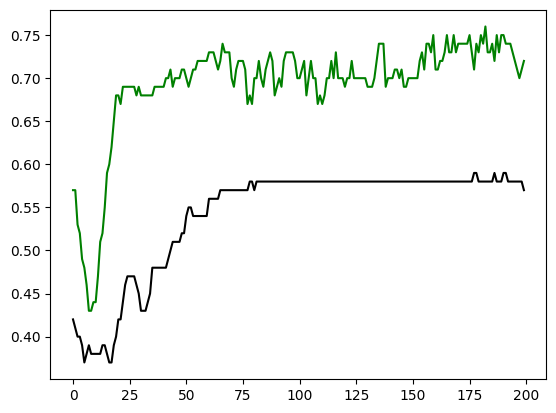

In [17]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')